# Decision 05 - Session Rules Anchored to Calendar QA

**Date:** 2026-02-11  
**Author:** Alex  
**Purpose:** define official intraday session rules (`premarket`, `rth`, `postmarket`) only for tickers/dates that passed Decision 04 lifecycle+calendar quality gate.  
**Status:** DRAFT

This notebook is a direct continuation of `01_calendar_definition.ipynb`.
First we trust official lifecycle/calendar and data quality gate, then we define intraday execution windows.

## Que hace este notebook (explicacion didactica y cientificamente exigente)

`05_session_rules.ipynb` transforma la validacion temporal del Decision 04 en una **tabla ejecutable de reglas intradia** por ticker y fecha.

Objetivo cientifico:
- pasar de evidencia de calendario/lifecycle (nivel diario) a ventanas horarias operativas (nivel intradia), sin introducir heuristicas no auditables.

Metodo aplicado:

1. Carga artefactos del ultimo run completo de `04_calendar_definition` y exige archivos minimos de trazabilidad.
2. Define `eligible_symbols`: ticker con lifecycle oficial y sin `FAIL` en datasets de gate.
3. Construye horario oficial `XNYS` con `exchange_calendars` y convierte aperturas/cierres a `America/New_York`.
4. Deriva sesiones deterministas por fecha:
   - `premarket`: `04:00:00` -> `rth_open - 1s`
   - `rth`: `rth_open` -> `rth_close`
   - `postmarket`: `rth_close + 1s` -> `20:00:00` (dia regular) o `17:00:00` (half-day)
5. Interseca calendario oficial con lifecycle de cada ticker y genera reglas por `ticker-date-session`.
6. Anexa politicas de inclusion (`signal_allowed`, `execution_allowed`) para que el motor consuma reglas listas para ejecucion.
7. Exporta artefactos versionados en `runs/data_quality/05_session_rules/<run_id>/`.

Traduccion operacional:
- este notebook no descubre sesiones desde los datos observados; las impone desde verdad oficial de mercado y lifecycle validado.
- asi se evita sesgo por huecos de datos, particiones rotas o relojes inconsistentes.


## Step 1 - Setup and run traceability

What we do:
- Initialize run folder and git traceability.
- Configure session policy knobs.

Why:
- Session rules must be reproducible and auditable, same standard as Decision 04.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import uuid
from datetime import datetime, timezone, time, timedelta
from pathlib import Path

import pandas as pd
import polars as pl

NOTEBOOK_ID = "05_session_rules"
try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    print("matplotlib not available:", e)

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
RUNS_DIR = Path(os.getenv("RUNS_DIR", PROJECT_ROOT / "runs")).resolve()
OUT_DIR = RUNS_DIR / "data_quality" / NOTEBOOK_ID / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT).decode().strip()
except Exception:
    git_commit = "<unknown>"

# Session policy
TIMEZONE_CANONICAL = "America/New_York"
SESSION_PREMARKET_START = "04:00:00"
SESSION_POSTMARKET_END_REGULAR = "20:00:00"
SESSION_POSTMARKET_END_HALFDAY = "17:00:00"

# Backtest inclusion policy (v1)
SIGNAL_ALLOWED = {"premarket", "rth"}
EXEC_ALLOWED = {"premarket", "rth"}

print("Run ID:", RUN_ID)
print("Out dir:", OUT_DIR)
print("Git commit:", git_commit)

Run ID: 20260211_191206_1cfd88a6
Out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\05_session_rules\20260211_191206_1cfd88a6
Git commit: 4f912b58d2cf5fe825b7735ab3ae668ce0781991


## Step 2 - Load artifacts from Decision 04

What we do:
- Load latest run from `runs/data_quality/04_calendar_definition`.
- Read:
  - `calendar_reconciliation_decision.json`
  - `official_lifecycle.parquet`
  - `calendar_reconciliation_by_ticker.parquet`

Why:
- Session rules must be built on the exact ticker/date universe validated in Decision 04.

What result means:
- `eligible_symbols` are symbols that have official lifecycle and no `FAIL` on gating datasets.

In [2]:
DEC04_ROOT = RUNS_DIR / "data_quality" / "04_calendar_definition"
if not DEC04_ROOT.exists():
    raise FileNotFoundError(f"Missing Decision 04 runs directory: {DEC04_ROOT}")

required = [
    "calendar_reconciliation_decision.json",
    "calendar_reconciliation_by_ticker.parquet",
    "official_lifecycle.parquet",
    "official_exchange_meta.parquet",
]

run_dirs = sorted([p for p in DEC04_ROOT.iterdir() if p.is_dir()], key=lambda x: x.stat().st_mtime, reverse=True)
if not run_dirs:
    raise RuntimeError("No Decision 04 runs found")

DEC04_RUN = None
for candidate in run_dirs:
    if all((candidate / f).exists() for f in required):
        DEC04_RUN = candidate
        break

if DEC04_RUN is None:
    raise RuntimeError("No complete Decision 04 run found with required artifacts")

print("Using Decision 04 run:", DEC04_RUN)

with open(DEC04_RUN / "calendar_reconciliation_decision.json", "r", encoding="utf-8") as f:
    dec04 = json.load(f)

recon04 = pl.read_parquet(DEC04_RUN / "calendar_reconciliation_by_ticker.parquet")
lifecycle = pl.read_parquet(DEC04_RUN / "official_lifecycle.parquet")

# Identify gating datasets exactly as produced in Decision 04.
if "gate_role" in recon04.columns:
    gating = recon04.filter(pl.col("gate_role") == "gating")
else:
    gating = recon04.filter(~pl.col("dataset").is_in(["quotes_p95"]))

# Eligible symbol: all gating statuses in {PASS,WARN} and lifecycle exists.
status_ok = (
    gating.group_by("ticker")
    .agg([
        pl.col("status").eq("FAIL").any().alias("has_fail"),
    ])
    .with_columns((~pl.col("has_fail")).alias("gating_ok"))
)

meta = (
    pl.read_parquet(DEC04_RUN / "official_exchange_meta.parquet")
    .select(["ticker", "official_lifecycle_found"])
)

elig = (
    meta.join(status_ok, on="ticker", how="left")
    .with_columns([
        pl.col("gating_ok").fill_null(False),
        (pl.col("official_lifecycle_found") & pl.col("gating_ok")).alias("eligible"),
    ])
)

eligible_symbols = elig.filter(pl.col("eligible"))[["ticker"]].to_series().to_list()
print("Eligible symbols:", eligible_symbols)

elig


Using Decision 01 run: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\04_calendar_definition\20260211_191200_35ebd0d1
Eligible symbols: ['AABA']


ticker,official_lifecycle_found,has_fail,gating_ok,eligible
str,bool,bool,bool,bool
"""AABA""",true,false,true,true


## Step 3 - Build official session schedule from exchange calendar

What we do:
- Use official `XNYS` schedule from `exchange_calendars`.
- For each trading date, extract official `rth_open` and `rth_close` in New York time.
- Mark half-days from official close time.
- Derive deterministic windows:
  - premarket: `04:00:00` -> `rth_open - 1s`
  - rth: `rth_open` -> `rth_close`
  - postmarket: `rth_close + 1s` -> `20:00:00` (regular) or `17:00:00` (half-day)

Why:
- Session boundaries come from exchange truth, not from ad-hoc assumptions.

In [3]:
try:
    import exchange_calendars as xc
except Exception as e:
    raise RuntimeError("exchange_calendars is required for official session schedule") from e

if len(eligible_symbols) == 0:
    raise RuntimeError("No eligible symbols from Decision 04; cannot build session rules")

lc = lifecycle.filter(pl.col("ticker").is_in(eligible_symbols))
start_date = str(lc["list_date"].min())

# Use max delist_date across eligible; fallback today for active symbols.
end_candidates = []
for r in lc.select(["delist_date"]).to_series().to_list():
    end_candidates.append(r if r is not None else pd.Timestamp.utcnow().date())
end_date = str(max(end_candidates))

cal = xc.get_calendar("XNYS")
sched = cal.schedule.loc[start_date:end_date].copy()

# Convert to NY local time for deterministic labels.
open_ny = sched["open"].dt.tz_convert(TIMEZONE_CANONICAL)
close_ny = sched["close"].dt.tz_convert(TIMEZONE_CANONICAL)

session_rows = []
for d, o, c in zip(sched.index, open_ny, close_ny):
    dd = pd.Timestamp(d).date()
    open_t = o.time()
    close_t = c.time()

    is_half_day = close_t < time(16, 0, 0)
    pm_start = (datetime.combine(dd, close_t) + timedelta(seconds=1)).time()
    pm_end = time.fromisoformat(SESSION_POSTMARKET_END_HALFDAY if is_half_day else SESSION_POSTMARKET_END_REGULAR)

    session_rows.append({
        "date": dd,
        "rth_open": open_t.isoformat(),
        "rth_close": close_t.isoformat(),
        "is_half_day": bool(is_half_day),
        "premarket_start": SESSION_PREMARKET_START,
        "premarket_end": (datetime.combine(dd, open_t) - timedelta(seconds=1)).time().isoformat(),
        "postmarket_start": pm_start.isoformat(),
        "postmarket_end": pm_end.isoformat(),
    })

official_session_calendar = pl.DataFrame(session_rows).sort("date")
print("Official trading dates:", official_session_calendar.height)
official_session_calendar.head(5)

Official trading dates: 578


date,rth_open,rth_close,is_half_day,premarket_start,premarket_end,postmarket_start,postmarket_end
date,str,str,bool,str,str,str,str
2017-06-16,"""09:30:00""","""16:00:00""",false,"""04:00:00""","""09:29:59""","""16:00:01""","""20:00:00"""
2017-06-19,"""09:30:00""","""16:00:00""",false,"""04:00:00""","""09:29:59""","""16:00:01""","""20:00:00"""
2017-06-20,"""09:30:00""","""16:00:00""",false,"""04:00:00""","""09:29:59""","""16:00:01""","""20:00:00"""
2017-06-21,"""09:30:00""","""16:00:00""",false,"""04:00:00""","""09:29:59""","""16:00:01""","""20:00:00"""
2017-06-22,"""09:30:00""","""16:00:00""",false,"""04:00:00""","""09:29:59""","""16:00:01""","""20:00:00"""


## Step 4 - Build per-symbol executable session calendar

What we do:
- Intersect each symbol lifecycle (`list_date` -> `delist_date`) with official session calendar dates.
- Attach inclusion flags per session (`signal_allowed`, `execution_allowed`).

Why:
- Produces the exact intraday rule table that the engine can consume per ticker/date.

In [4]:
rows = []
for r in lc.to_dicts():
    sym = r["ticker"]
    lo = r["list_date"]
    hi = r["delist_date"] if r["delist_date"] is not None else pd.Timestamp.utcnow().date()

    s = official_session_calendar.filter((pl.col("date") >= lo) & (pl.col("date") <= hi))
    for rr in s.to_dicts():
        rows.append({
            "ticker": sym,
            "date": rr["date"],
            "session": "premarket",
            "start": rr["premarket_start"],
            "end": rr["premarket_end"],
            "is_half_day": rr["is_half_day"],
            "signal_allowed": "premarket" in SIGNAL_ALLOWED,
            "execution_allowed": "premarket" in EXEC_ALLOWED,
        })
        rows.append({
            "ticker": sym,
            "date": rr["date"],
            "session": "rth",
            "start": rr["rth_open"],
            "end": rr["rth_close"],
            "is_half_day": rr["is_half_day"],
            "signal_allowed": "rth" in SIGNAL_ALLOWED,
            "execution_allowed": "rth" in EXEC_ALLOWED,
        })
        rows.append({
            "ticker": sym,
            "date": rr["date"],
            "session": "postmarket",
            "start": rr["postmarket_start"],
            "end": rr["postmarket_end"],
            "is_half_day": rr["is_half_day"],
            "signal_allowed": "postmarket" in SIGNAL_ALLOWED,
            "execution_allowed": "postmarket" in EXEC_ALLOWED,
        })

symbol_session_rules = pl.DataFrame(rows).sort(["ticker", "date", "session"])

summary = (
    symbol_session_rules
    .group_by(["ticker", "session"])
    .agg([
        pl.len().alias("n_rows"),
        pl.col("is_half_day").sum().alias("n_half_days"),
        pl.col("execution_allowed").all().alias("execution_always_allowed"),
    ])
    .sort(["ticker", "session"])
)

symbol_session_rules.head(9), summary

(shape: (9, 8)
 ┌────────┬────────────┬────────────┬──────────┬──────────┬─────────────┬─────────────┬─────────────┐
 │ ticker ┆ date       ┆ session    ┆ start    ┆ end      ┆ is_half_day ┆ signal_allo ┆ execution_a │
 │ ---    ┆ ---        ┆ ---        ┆ ---      ┆ ---      ┆ ---         ┆ wed         ┆ llowed      │
 │ str    ┆ date       ┆ str        ┆ str      ┆ str      ┆ bool        ┆ ---         ┆ ---         │
 │        ┆            ┆            ┆          ┆          ┆             ┆ bool        ┆ bool        │
 ╞════════╪════════════╪════════════╪══════════╪══════════╪═════════════╪═════════════╪═════════════╡
 │ AABA   ┆ 2017-06-16 ┆ postmarket ┆ 16:00:01 ┆ 20:00:00 ┆ false       ┆ false       ┆ false       │
 │ AABA   ┆ 2017-06-16 ┆ premarket  ┆ 04:00:00 ┆ 09:29:59 ┆ false       ┆ true        ┆ true        │
 │ AABA   ┆ 2017-06-16 ┆ rth        ┆ 09:30:00 ┆ 16:00:00 ┆ false       ┆ true        ┆ true        │
 │ AABA   ┆ 2017-06-19 ┆ postmarket ┆ 16:00:01 ┆ 20:00:00 ┆ false  

## Step 5 - Visual diagnostics

What we show:
- Plot 1: tradable days per year for each eligible symbol.
- Plot 2: half-days per year.
- Plot 3: count of session rows by session type.

Why:
- Quick sanity check before connecting to execution/fill logic.

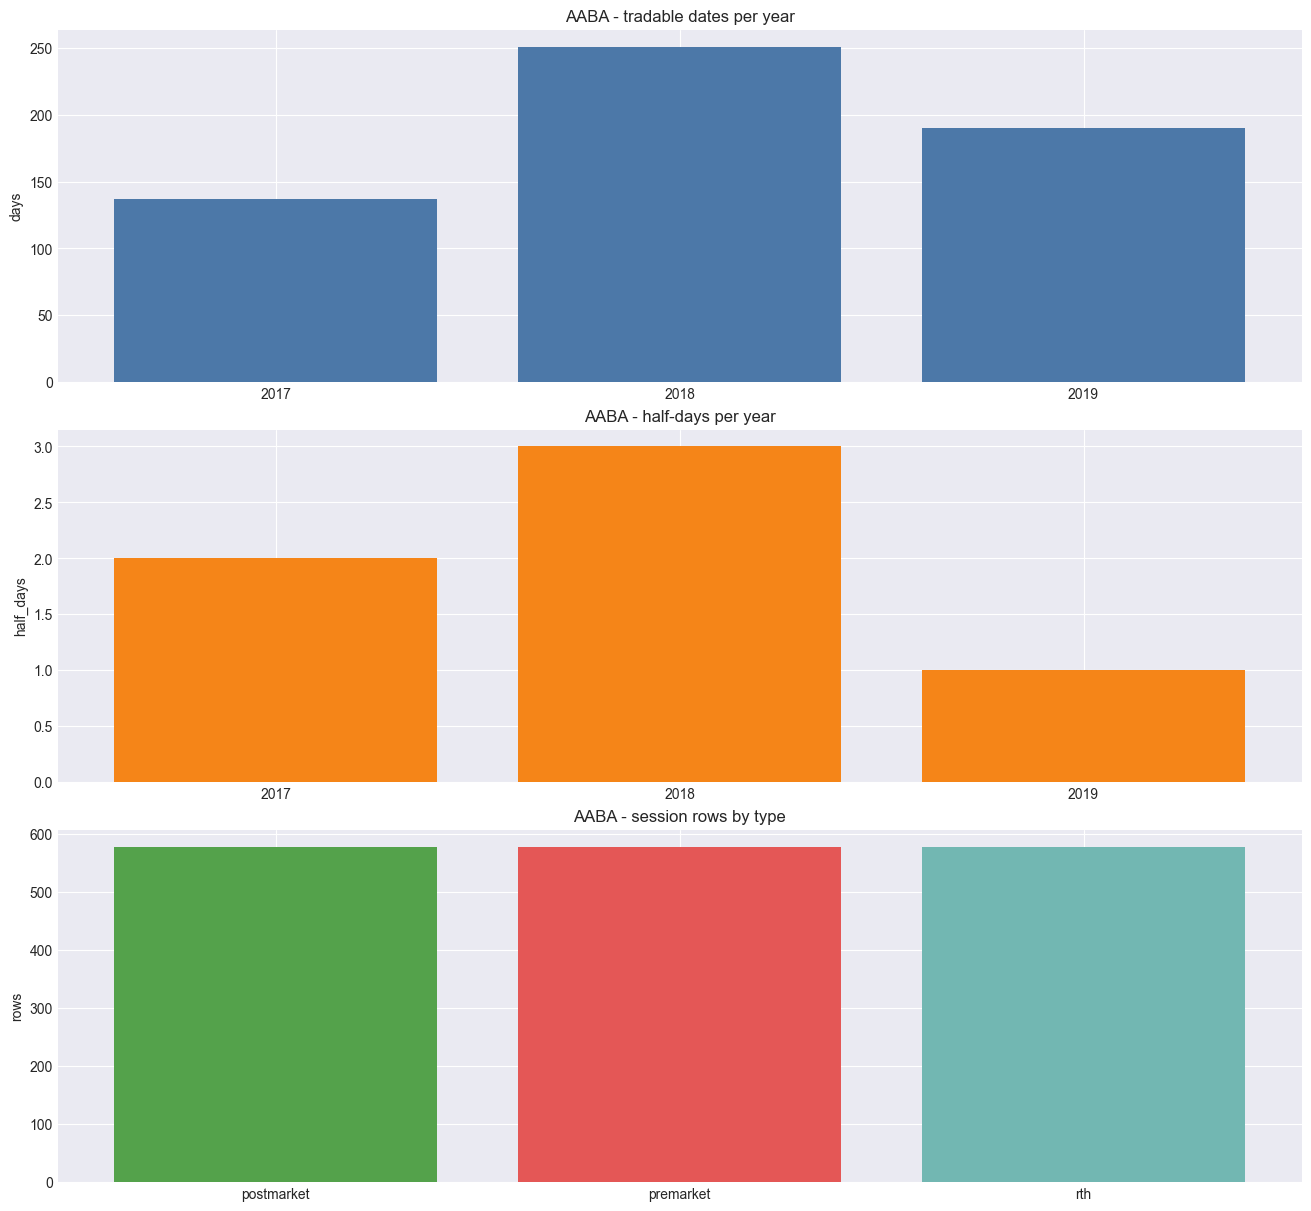

In [5]:
if plt is not None and symbol_session_rules.height > 0:
    plt.style.use("seaborn-v0_8-darkgrid")

    for sym in eligible_symbols:
        sdf = symbol_session_rules.filter(pl.col("ticker") == sym)
        daily = (
            sdf.select(["date", "is_half_day"]).unique()
            .with_columns(pl.col("date").dt.year().alias("year"))
        )

        days_by_year = daily.group_by("year").len().sort("year").to_pandas()
        half_by_year = daily.filter(pl.col("is_half_day")).group_by("year").len().sort("year").to_pandas()
        sess_count = sdf.group_by("session").len().sort("session").to_pandas()

        fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(13, 12), constrained_layout=True)

        axes[0].bar(days_by_year["year"].astype(str), days_by_year["len"], color="#4c78a8")
        axes[0].set_title(f"{sym} - tradable dates per year")
        axes[0].set_ylabel("days")

        if len(half_by_year) > 0:
            axes[1].bar(half_by_year["year"].astype(str), half_by_year["len"], color="#f58518")
        axes[1].set_title(f"{sym} - half-days per year")
        axes[1].set_ylabel("half_days")

        axes[2].bar(sess_count["session"], sess_count["len"], color=["#54a24b", "#e45756", "#72b7b2"])
        axes[2].set_title(f"{sym} - session rows by type")
        axes[2].set_ylabel("rows")

        plt.show()

## Step 6 - Export artifacts for engine consumption

What we export:
- `session_rules_decision.json`: policy + provenance + Decision 04 dependency.
- `official_session_calendar.parquet`: exchange-level date/session table.
- `symbol_session_rules.parquet`: per symbol/date/session executable rules.
- `symbol_session_summary.parquet`: quick QA summary.

Why:
- Engine can consume deterministic rules without recomputing notebook logic.

In [6]:
session_rules_decision = {
    "decision_id": "session_rules_official_v2",
    "version": "2.0.0",
    "as_of_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_commit,
    "depends_on_decision_04_run": str(DEC04_RUN),
    "timezone_canonical": TIMEZONE_CANONICAL,
    "policy": {
        "premarket_start": SESSION_PREMARKET_START,
        "postmarket_end_regular": SESSION_POSTMARKET_END_REGULAR,
        "postmarket_end_halfday": SESSION_POSTMARKET_END_HALFDAY,
        "signal_allowed": sorted(list(SIGNAL_ALLOWED)),
        "execution_allowed": sorted(list(EXEC_ALLOWED)),
    },
    "eligible_symbols": eligible_symbols,
    "n_eligible_symbols": len(eligible_symbols),
}

with open(OUT_DIR / "session_rules_decision.json", "w", encoding="utf-8") as f:
    json.dump(session_rules_decision, f, indent=2)

official_session_calendar.write_parquet(OUT_DIR / "official_session_calendar.parquet")
symbol_session_rules.write_parquet(OUT_DIR / "symbol_session_rules.parquet")
summary.write_parquet(OUT_DIR / "symbol_session_summary.parquet")

print("Saved:", OUT_DIR / "session_rules_decision.json")
print("Saved:", OUT_DIR / "official_session_calendar.parquet")
print("Saved:", OUT_DIR / "symbol_session_rules.parquet")
print("Saved:", OUT_DIR / "symbol_session_summary.parquet")

Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\05_session_rules\20260211_191206_1cfd88a6\session_rules_decision.json
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\05_session_rules\20260211_191206_1cfd88a6\official_session_calendar.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\05_session_rules\20260211_191206_1cfd88a6\symbol_session_rules.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\05_session_rules\20260211_191206_1cfd88a6\symbol_session_summary.parquet


### Interpretacion final (lectura de calidad y riesgo)

Como evaluar cientificamente la salida:

- Si `n_eligible_symbols` es bajo o cero, no hay universo confiable para reglas intradia; el problema viene de Decision 04, no de sesiones.
- `official_session_calendar.parquet` debe reflejar aperturas/cierres oficiales y distinguir correctamente `is_half_day`.
- `symbol_session_rules.parquet` debe contener exactamente 3 sesiones por `ticker-date` (premarket/rth/postmarket), con intervalos no solapados y cronologicamente consistentes.
- `symbol_session_summary.parquet` debe ser coherente con el calendario anual (dias operables y half-days por anio).
- Si la politica (`signal_allowed`, `execution_allowed`) cambia, debe cambiar tambien `session_rules_decision.json` para mantener reproducibilidad experimental.

Artefactos criticos exportados:
- `session_rules_decision.json`
- `official_session_calendar.parquet`
- `symbol_session_rules.parquet`
- `symbol_session_summary.parquet`

Conclusion metodologica:
este notebook fija el contrato intradia que consumira el motor; si este contrato no es consistente, cualquier backtest posterior mezcla errores de calendario con supuesta senal de mercado.


## Conclusion

Decision 05 is now fully coupled to Decision 04 artifacts.
This means session rules are official, reproducible, and applied only to validated ticker/date universes.